#This is the start of this Project

In [1]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

In [7]:
DATASET_PATH = "dataset"
train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [9]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 16504 files belonging to 15 classes.
Found 2070 files belonging to 15 classes.
Found 2064 files belonging to 15 classes.


In [11]:
class_names = train_ds.class_names
print("Classes:", class_names)

import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = []
if 'train_dir' in globals():
    for label_idx, cls in enumerate(class_names):
        count = len(os.listdir(os.path.join(train_dir, cls)))
        labels.extend([label_idx] * count)

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
    class_weights_dict = dict(enumerate(class_weights))
    print("Class Weights Calculated:", class_weights_dict)
else:
    class_weights_dict = None


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Class Weights Calculated: {0: 1.3805102467586783, 1: 0.9308516638465877, 2: 1.3753333333333333, 3: 1.3753333333333333, 4: 9.093112947658403, 5: 0.6468351949833432, 6: 1.3753333333333333, 7: 0.7205413665138616, 8: 1.4458169075777485, 9: 0.7770244821092279, 10: 0.8210945273631841, 11: 0.9797566043336302, 12: 0.42878669784359574, 13: 3.6921700223713647, 14: 0.8649895178197065}


# Data Augmentation

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

Normalization Layer

In [14]:
# normalization_layer = layers.Rescaling(1./255)
from tensorflow.keras.applications.efficientnet import preprocess_input
tf.keras.applications.efficientnet.preprocess_input

<function keras.src.applications.efficientnet.preprocess_input(x, data_format=None)>

Load EfficientNetB0 (Transfer Learning)

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

In [16]:
base_model.trainable = False

In [17]:
num_classes = len(class_names)

inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
# x = normalization_layer(x)
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,482 (16.73 MB)

 Trainable params: 334,351 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [20]:
class StopAtAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.95):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("val_accuracy")
        if acc is not None and acc >= self.target:
            print(f"\n✅ Reached {self.target*100}% accuracy. Stopping training.")
            self.model.stop_training = True

In [21]:
callbacks = [
    StopAtAccuracy(target=0.95),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/20


516/516 ━━━━━━━━━━━━━━━━━━━━ 1088s 2s/step - accuracy: 0.4740 - loss: 1.7241 - val_accuracy: 0.7478 - val_loss: 0.7768 - learning_rate: 1.0000e-04
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - accuracy: 0.7149 - loss: 0.8487 - val_accuracy: 0.8348 - val_loss: 0.5121 - learning_rate: 1.0000e-04
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 419s 812ms/step - accuracy: 0.7737 - loss: 0.6634 - val_accuracy: 0.8657 - val_loss: 0.4084 - learning_rate: 1.0000e-04
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 355s 687ms/step - accuracy: 0.8112 - loss: 0.5585 - val_accuracy: 0.8836 - val_loss: 0.3521 - learning_rate: 1.0000e-04
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 430s 832ms/step - accuracy: 0.8343 - loss: 0.4856 - val_accuracy: 0.8957 - val_loss: 0.3106 - learning_rate: 1.0000e-04
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 429s 830ms/step - accuracy: 0.8459 - loss: 0.4396 - val_accuracy: 0.8986 - val_loss: 0.2895 - learning_rate: 1.0000e-04
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 54953s 107s/step

In [27]:
base_model.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True


In [28]:
for images, labels in train_ds.take(1):
    print("Labels:", labels[:20])

Labels: tf.Tensor([12  7  9 14 14  9 10  2  3 10 12 10 11  8 14  9  7  3 14  2], shape=(20,), dtype=int32)


In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
fine_tune_epochs = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    class_weight=class_weights_dict
)

Epoch 1/10


516/516 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.9120 - loss: 0.2383 - val_accuracy: 0.9420 - val_loss: 0.1763
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 513s 994ms/step - accuracy: 0.9158 - loss: 0.2313 - val_accuracy: 0.9478 - val_loss: 0.1644
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 485s 940ms/step - accuracy: 0.9209 - loss: 0.2201 - val_accuracy: 0.9493 - val_loss: 0.1583
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1021s 2s/step - accuracy: 0.9224 - loss: 0.2122 - val_accuracy: 0.9488 - val_loss: 0.1501
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 1157s 2s/step - accuracy: 0.9311 - loss: 0.1950 - val_accuracy: 0.9522 - val_loss: 0.1461
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 505s 978ms/step - accuracy: 0.9297 - loss: 0.1999 - val_accuracy: 0.9527 - val_loss: 0.1368
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 521s 1s/step - accuracy: 0.9333 - loss: 0.1850 - val_accuracy: 0.9541 - val_loss: 0.1340
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - accuracy: 0.9347 - loss: 0.1804 - val_accu

In [31]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

65/65 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9608 - loss: 0.1156
Test Accuracy: 0.9607558250427246


In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [35]:
y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 524ms/step


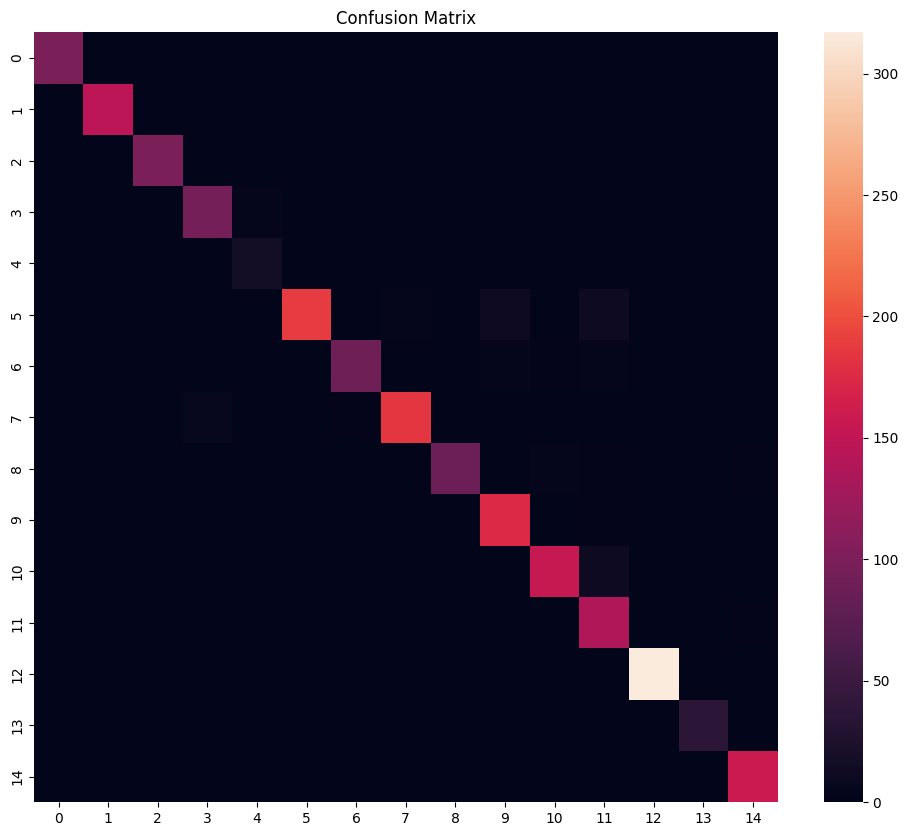

In [36]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.show()

In [37]:
model.save("saved_models/model.keras")

In [38]:
model.save("saved_models/plant_disease_model.h5")

In [40]:
tf.keras.models.load_model("saved_models/plant_disease_model.keras")

<Functional name=functional_1, built=True>

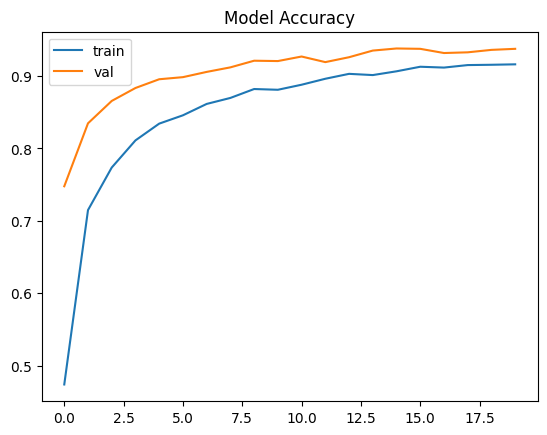

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['train','val'])
plt.show()